In [2]:
!pip install sklearn-genetic

     |████████████████████████████████| 163kB 4.5MB/s 
  Created wheel for sklearn-genetic: filename=sklearn_genetic-0.2-py2.py3-none-any.whl size=6695 sha256=6efecd02678953a56cb1b712dbc2d4ba326e8f5953639f798a38130b94ba054e
  Stored in directory: /root/.cache/pip/wheels/e0/0d/a7/698bc5a79bdf76ad619116359c01dcc40298b8b275279fd826
Successfully built sklearn-genetic


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import genetic_selection

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.metrics.scorer module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.metrics. Anything that cannot be imported from sklearn.metrics is now part of the private API.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.feature_selection.base module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.feature_selection. Anything that cannot be imported from sklearn.feature_selection is now part of the private API.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/externals/joblib/__init__.py:15: FutureWarning: sklearn.externals.joblib is deprecated in 0.21 and will be removed in 0

In [ ]:
def feno(x):
    fr1 = 1.8
    fr2 = 100
    fa1 = 0.8*np.pi
    k = 0.8
    y = (np.sin(x*fr1*np.pi-fa1)+0.25*np.sin(x*fr2*np.pi))*np.exp(-k*x)
    return y

def fitness(x):
    # y: debe ser siempre mayor o igual que 0
    #    los valores mas altos de y indican mejor desempeno
    # X: es la salida de la funcion feno
    y = np.abs(x)
    return y

def mutacion(p1):
    n1 = len(p1)
    t1 = list(p1)
    it1 = np.random.choice(np.linspace(0,n1-1,n1),1,True,np.ones(n1)/n1)
    d1a = np.random.choice(np.array([0,1]),1,True,np.array([1,1])/2)
    d1 = np.array2string(d1a[0])
    t1[int(it1[0])] = d1
    m1 = "".join(t1)
    return m1


In [ ]:

def select(x,metodo):
    # x: debe ser resultado de la funcion fitness
    nx = len(x);
    if metodo == "ruleta":
        ix = np.random.choice(np.linspace(0,nx-1,nx),1,True,x/np.sum(x))
    elif metodo == "rank.s":
        pc = 0.9
        kr1 = np.linspace(1,nx,nx)
        ranking_de_poblacion = (pc**kr1)*((1.0-pc)**(kr1-1.0))
        ranking_de_poblacion = ranking_de_poblacion / np.sum(ranking_de_poblacion)
        ix1 = np.argsort(x)
        ix = np.random.choice(np.linspace(0,nx-1,nx),
                              1,
                              True,
                              ranking_de_poblacion[ix1])        
    else:
        ix = np.random.choice(np.linspace(0,nx-1,nx),1,True,np.ones(nx)/nx)
    return ix

def cruce(p1,p2):
    n1 = len(p1)
    n2 = int(np.floor(n1/2))
    tp1 = list(p1)
    tp2 = list(p2)
    th1 = tp1[0:n2]+tp2[n2:n1+1]
    th2 = tp2[0:n2]+tp1[n2:n1+1]
    h1 = "".join(th1)
    h2 = "".join(th2)
    return [h1,h2]

In [ ]:
# nb: numero de bits (genes) de cada individuo
nb = 14
# n: numero de datos para mostrar la senal a optimizar
n=1000
x = np.linspace(0,n,n+1)/n
# funcion (fenotipo) de la senal
y = feno(x)
# m: numero de individuos de la poblacion
m=20
pob = np.random.uniform(0.0,1.0,m)
ypob = feno(pob)
pob_original = copy.deepcopy(pob)
ypob_original = copy.deepcopy(ypob)
bestfit = 0
gen = []
for p1 in pob:
    p1t = int(np.round(p1*(2**nb-1)))
    gen.append(np.binary_repr(p1t,nb))

# maximo numero de iteraciones sin que bestfit cambie
iteraciones = 1000
k2 = 1
while k2<iteraciones:
      ypob = feno(pob)
      gen = []
      for p1 in pob:
          p1t = int(np.round(p1*(2**nb-1)))
          gen.append(np.binary_repr(p1t,nb))
      fpob = fitness(ypob)
      vfp = np.amax(fpob)
      ifp = np.argmax(fpob)
      if vfp>bestfit:
          bestfit = vfp
          xbf = pob[ifp];
          ybf = ypob[ifp];
          print("Mejor solución hasta el momento")
          print([k2,bestfit,xbf,ybf])
          k2 = 1;
      else:
          k2=k2+1;
      generacion = [];
      # Se crea la nueva generacion
      for k1 in range(1,int(m/2)+1):
          # Modo Ruleta
          #h1 = gen[int(select(fpob,"ruleta"))]
          #h2 = gen[int(select(fpob,"ruleta"))]
          # Modo Rank Space
          h1 = gen[int(select(fpob,"rank.s"))]
          h2 = gen[int(select(fpob,"rank.s"))]
          # Modo Aleatorio Uniforme
          #h1 = gen[int(select(fpob,"unifor"))]
          #h2 = gen[int(select(fpob,"unifor"))]
          [g1,g2] = cruce(h1,h2)
          # Prueben comentando o eliminando las lineas
          # de las mutaciones para que vean el efecto en la convergencia
          g1 = mutacion(g1)
          g2 = mutacion(g2)
          generacion.append(g1)
          generacion.append(g2)
      k3 = 0;
      for gent in generacion:
          pob[k3] = (int(gent,2)+0.0)/(2**nb)
          k3 = k3+1
print("Mejor solución")
print(xbf)
print(ybf)

Mejor solución hasta el momento
[1, 0.9236879378006263, 0.23258160243603143, -0.9236879378006263]
Mejor solución hasta el momento
[1, 1.047328252055073, 0.11279296875, -1.047328252055073]
Mejor solución hasta el momento
[5, 1.0539431827089076, 0.0966796875, -1.0539431827089076]
Mejor solución hasta el momento
[4, 1.0688277933693222, 0.09619140625, -1.0688277933693222]
Mejor solución hasta el momento
[104, 1.085309279577772, 0.17474365234375, -1.085309279577772]
Mejor solución hasta el momento
[15, 1.1023095885387773, 0.15496826171875, -1.1023095885387773]
Mejor solución hasta el momento
[821, 1.1065880738091525, 0.13531494140625, -1.1065880738091525]
Mejor solución
0.13531494140625
-1.1065880738091525


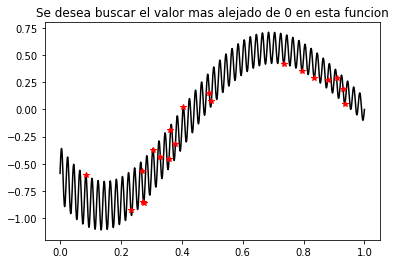

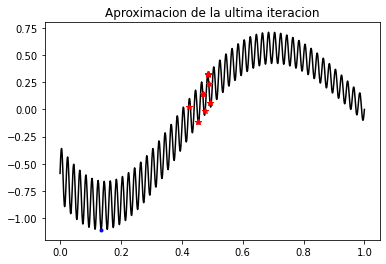

In [ ]:
plt.figure()
plt.plot(x,y,'k')
plt.title("Se desea buscar el valor mas alejado de 0 en esta funcion")
plt.plot(pob_original, ypob_original, '*r')
plt.show()
yfinal = feno(pob)
plt.figure()
plt.plot(x,y,'k')
plt.plot(pob,yfinal,'*r')
plt.plot(xbf,ybf,'.b')
plt.title("Aproximacion de la ultima iteracion")
#plt.legend("fenotipo","poblacion","mejor solucion")
plt.show()
